In [7]:
!pip install anndata==0.8.0

In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from sklearn.neighbors import KernelDensity
import time
import dill
import pickle
from scipy.spatial import distance
import os
import scipy

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open('parent_dict.pkl', 'rb') as f:
    parent_dict = pickle.load(f)

In [2]:
fn = 'Active_SAM_joined/SAM_AC_ncbi_soupx_cleaned_03122025.h5ad'

In [3]:
sam = SAM()
sam.load_data(fn)

In [6]:
lsaturn_mv = pd.read_csv('SATURN_mapping/AC_vole_mouse_SATURN_30_seed.csv', index_col = 'Unnamed: 0')
lsaturn_m = pd.read_csv('SATURN_mapping/AC_30_seeds.csv', index_col = 'barcode')

In [7]:
ind = pd.read_csv('Active_SAMap_Joined/AC_MG_mapping_cleaned_03122025_0.csv')['Unnamed: 0']
lsamap_m = pd.DataFrame(index = list(ind))
for i in range(30):
    df = pd.read_csv('Active_SAMap_Joined/AC_MG_mapping_cleaned_03122025_' + str(i) + '.csv', index_col = 'Unnamed: 0')
    lsamap_m = pd.concat([lsamap_m, df], axis = 1)

In [8]:
lsamap_m

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
AAACCCAGTTTGGAAA,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,...,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN
AAACGAAAGGACTGGT,239 MARN-GRN Pyy Glut,239 MARN-GRN Pyy Glut,239 MARN-GRN Pyy Glut,239 MARN-GRN Pyy Glut,239 MARN-GRN Pyy Glut,239 MARN-GRN Pyy Glut,239 MARN-GRN Pyy Glut,239 MARN-GRN Pyy Glut,239 MARN-GRN Pyy Glut,239 MARN-GRN Pyy Glut,...,239 MARN-GRN Pyy Glut,239 MARN-GRN Pyy Glut,239 MARN-GRN Pyy Glut,239 MARN-GRN Pyy Glut,239 MARN-GRN Pyy Glut,239 MARN-GRN Pyy Glut,239 MARN-GRN Pyy Glut,239 MARN-GRN Pyy Glut,239 MARN-GRN Pyy Glut,239 MARN-GRN Pyy Glut
AAACGAACAAGAGATT,213 SCsg Gabrr2 Gaba,213 SCsg Gabrr2 Gaba,213 SCsg Gabrr2 Gaba,213 SCsg Gabrr2 Gaba,213 SCsg Gabrr2 Gaba,213 SCsg Gabrr2 Gaba,213 SCsg Gabrr2 Gaba,213 SCsg Gabrr2 Gaba,213 SCsg Gabrr2 Gaba,213 SCsg Gabrr2 Gaba,...,213 SCsg Gabrr2 Gaba,213 SCsg Gabrr2 Gaba,213 SCsg Gabrr2 Gaba,213 SCsg Gabrr2 Gaba,213 SCsg Gabrr2 Gaba,213 SCsg Gabrr2 Gaba,213 SCsg Gabrr2 Gaba,213 SCsg Gabrr2 Gaba,213 SCsg Gabrr2 Gaba,213 SCsg Gabrr2 Gaba
AAACGAACATGACGTT,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,...,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN
AAACGCTTCCTAGCGG,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,...,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGTCATATGGC,207 SCs Dmbx1 Gaba,207 SCs Dmbx1 Gaba,207 SCs Dmbx1 Gaba,207 SCs Dmbx1 Gaba,207 SCs Dmbx1 Gaba,207 SCs Dmbx1 Gaba,207 SCs Dmbx1 Gaba,207 SCs Dmbx1 Gaba,207 SCs Dmbx1 Gaba,207 SCs Dmbx1 Gaba,...,207 SCs Dmbx1 Gaba,207 SCs Dmbx1 Gaba,207 SCs Dmbx1 Gaba,207 SCs Dmbx1 Gaba,207 SCs Dmbx1 Gaba,207 SCs Dmbx1 Gaba,207 SCs Dmbx1 Gaba,207 SCs Dmbx1 Gaba,207 SCs Dmbx1 Gaba,207 SCs Dmbx1 Gaba
TTTGTTGTCCAAACCA,014 LA-BLA-BMA-PA Glut,014 LA-BLA-BMA-PA Glut,014 LA-BLA-BMA-PA Glut,014 LA-BLA-BMA-PA Glut,014 LA-BLA-BMA-PA Glut,014 LA-BLA-BMA-PA Glut,014 LA-BLA-BMA-PA Glut,014 LA-BLA-BMA-PA Glut,022 L5 ET CTX Glut,023 SUB-ProS Glut,...,014 LA-BLA-BMA-PA Glut,014 LA-BLA-BMA-PA Glut,014 LA-BLA-BMA-PA Glut,014 LA-BLA-BMA-PA Glut,014 LA-BLA-BMA-PA Glut,022 L5 ET CTX Glut,014 LA-BLA-BMA-PA Glut,014 LA-BLA-BMA-PA Glut,014 LA-BLA-BMA-PA Glut,014 LA-BLA-BMA-PA Glut
TTTGTTGTCGCAGTCG,106 PVpo-VMPO-MPN Hmx2 Gaba,106 PVpo-VMPO-MPN Hmx2 Gaba,106 PVpo-VMPO-MPN Hmx2 Gaba,106 PVpo-VMPO-MPN Hmx2 Gaba,106 PVpo-VMPO-MPN Hmx2 Gaba,106 PVpo-VMPO-MPN Hmx2 Gaba,106 PVpo-VMPO-MPN Hmx2 Gaba,106 PVpo-VMPO-MPN Hmx2 Gaba,106 PVpo-VMPO-MPN Hmx2 Gaba,106 PVpo-VMPO-MPN Hmx2 Gaba,...,106 PVpo-VMPO-MPN Hmx2 Gaba,106 PVpo-VMPO-MPN Hmx2 Gaba,106 PVpo-VMPO-MPN Hmx2 Gaba,106 PVpo-VMPO-MPN Hmx2 Gaba,106 PVpo-VMPO-MPN Hmx2 Gaba,106 PVpo-VMPO-MPN Hmx2 Gaba,106 PVpo-VMPO-MPN Hmx2 Gaba,106 PVpo-VMPO-MPN Hmx2 Gaba,106 PVpo-VMPO-MPN Hmx2 Gaba,106 PVpo-VMPO-MPN Hmx2 Gaba
TTTGTTGTCTACTCAT,175 SC Bnc2 Glut,175 SC Bnc2 Glut,175 SC Bnc2 Glut,175 SC Bnc2 Glut,175 SC Bnc2 Glut,175 SC Bnc2 Glut,175 SC Bnc2 Glut,175 SC Bnc2 Glut,175 SC Bnc2 Glut,175 SC Bnc2 Glut,...,175 SC Bnc2 Glut,175 SC Bnc2 Glut,175 SC Bnc2 Glut,175 SC Bnc2 Glut,175 SC Bnc2 Glut,175 SC Bnc2 Glut,175 SC Bnc2 Glut,175 SC Bnc2 Glut,175 SC Bnc2 Glut,175 SC Bnc2 Glut


In [9]:
meta_folder = 'Active_SAMap_Joined/AC_metadata/'

In [10]:
mn = os.listdir('Active_SAMap_Joined/AC_metadata/')

In [11]:
pd.read_csv(meta_folder + mn[3])

,Unnamed: 0,orig.ident,nCount_RNA,nFeature_RNA,n_counts,n_genes,key,eq_subclass,eq_subclass_lc,eq_subclass_frac,...,neurotransmitter,eq_subclass_nounlabeled_NN,eq_subclass_nounlabeled_nmm,nCount_SCT,nFeature_SCT,SCT_snn_res.0.8,seurat_clusters,SCT_snn_res.5,subclass_id_label_mapping,subclass_id_label_lc
0,AAACCCAGTTTGGAAA,AC,2108.0,1113,2108.0,1113,Run12_sample1,327 Oligo NN,44,1.0,...,unclear,327 Oligo NN,327 Oligo NN,2807.0,1105,2,10,10,327 Oligo NN,32
1,AAACGAAAGGACTGGT,AC,2050.0,1078,2050.0,1078,Run12_sample1,Unlabeled,164,1.0,...,Gaba,ac_35,ac_35,2832.0,1071,21,33,33,Unlabeled,167
2,AAACGAACAAGAGATT,AC,4400.0,2075,4400.0,2075,Run12_sample1,Unlabeled,5,1.0,...,Gaba,ac_9,ac_9,3810.0,2050,20,31,31,Unlabeled,5
3,AAACGAACATGACGTT,AC,2572.0,1336,2572.0,1336,Run12_sample1,327 Oligo NN,12,1.0,...,unclear,327 Oligo NN,327 Oligo NN,2905.0,1320,2,30,30,327 Oligo NN,267
4,AAACGCTTCCTAGCGG,AC,7505.0,2390,7505.0,2390,Run12_sample1,327 Oligo NN,137,1.0,...,unclear,327 Oligo NN,327 Oligo NN,4082.0,1961,33,66,66,327 Oligo NN,139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47895,TTTGTTGTCATATGGC,AC,2901.0,1549,2901.0,1549,Run17_sample4,Unlabeled,268,1.0,...,Gaba,ac_24,cj_ac_7,3488.0,1546,6,39,39,Unlabeled,254
47896,TTTGTTGTCCAAACCA,AC,8108.0,3072,8108.0,3072,Run17_sample4,Unlabeled,113,1.0,...,Glut,ac_29,ac_29,4892.0,2746,17,79,79,Unlabeled,117
47897,TTTGTTGTCGCAGTCG,AC,2290.0,1251,2290.0,1251,Run17_sample4,106 PVpo-VMPO-MPN Hmx2 Gaba,83,1.0,...,Gaba,106 PVpo-VMPO-MPN Hmx2 Gaba,106 PVpo-VMPO-MPN Hmx2 Gaba,3408.0,1251,0,50,50,106 PVpo-VMPO-MPN Hmx2 Gaba,88
47898,TTTGTTGTCTACTCAT,AC,2500.0,1452,2500.0,1452,Run17_sample4,Unlabeled,100,1.0,...,Glut,ac_16,ac_16,3395.0,1448,1,18,18,Unlabeled,126


In [12]:
test = pd.read_csv(meta_folder + mn[0])['subclass_id_label_mapping']

In [13]:
barcodes = pd.read_csv(meta_folder + mn[0])['Unnamed: 0']

In [14]:
raw_lc = pd.read_csv(meta_folder + mn[0])['subclass_id_label_lc']

In [15]:
df_lc = pd.DataFrame(data = list(raw_lc), index = list(barcodes), columns = ['raw_lc'])

In [16]:
mode_df = pd.DataFrame(index = [a for a in range(len(test))], columns = [b for b in range(len(mn))])
for j in range(len(mn)):
    print(mn[j])
    dat = list(pd.read_csv(meta_folder + mn[j])['subclass_id_label_lc'])
    mode_df.loc[:,j] = dat

AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_12.csv
AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_27.csv
AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_19.csv
AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_29.csv
AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_22.csv
AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_10.csv
AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_5.csv
AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_14.csv
AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_7.csv
AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_17.csv
AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_8.csv
AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_24.csv
AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_21.csv
AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_2.csv
AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_16.csv
AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_6.csv
AC_ncbi_soupx_metadata_subclass_250_cleaned_0

In [17]:
fin = []
for item in mode_df.columns:
    fin.append(mode_df.loc[10000,item])

In [18]:
scipy.stats.mode(fin)

ModeResult(mode=array([243]), count=array([30]))

In [19]:
import re

mn = sorted(mn, key=lambda s: [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', s)])

In [20]:
mn

['AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_0.csv',
 'AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_1.csv',
 'AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_2.csv',
 'AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_3.csv',
 'AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_4.csv',
 'AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_5.csv',
 'AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_6.csv',
 'AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_7.csv',
 'AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_8.csv',
 'AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_9.csv',
 'AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_10.csv',
 'AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_11.csv',
 'AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_12.csv',
 'AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_13.csv',
 'AC_ncbi_soupx_metadata_subclass_250_cleaned_03122025_14.csv',
 'AC_ncbi_soupx_metadata_subclass_250_cleaned_0312

In [21]:
lsamap_mv = pd.DataFrame(index = [a for a in barcodes], columns = [b for b in range(len(mn))])
for j in range(len(mn)):
    dat = list(pd.read_csv(meta_folder + mn[j])['subclass_id_label_mapping'])
    lsamap_mv.loc[:,j] = dat

In [ ]:
#lsamap_m = lsamap_mv

In [51]:
#for quail
threshold = 0
a = 0
b = 0
mapping_dict ={}
for lc in sam.adata.obs['eq_subclass_lc'].unique():
    a += 1
    inp = ['Unlabeled', 'Unlabeled', 'Unlabeled']
    barcodes = sam.adata.obs_names[sam.adata.obs['eq_subclass_lc'] == lc]
    ct_saturn_mv = lsaturn_mv[lsaturn_mv.index.isin(barcodes)].values.ravel()
    ct_saturn_m = lsaturn_m[lsaturn_m.index.isin(barcodes)].values.ravel()
    ct_samap_mv = lsamap_mv[lsamap_mv.index.isin(barcodes)].values.ravel()
    ct_samap_m = lsamap_m[lsamap_m.index.isin(barcodes)].values.ravel()
    
    mode_saturn_mv,f_saturn_mv = scipy.stats.mode(ct_saturn_mv)
    mode_saturn_m,f_saturn_m = scipy.stats.mode(ct_saturn_m)
    mode_samap_mv,f_samap_mv = scipy.stats.mode(ct_samap_mv)
    mode_samap_m,f_samap_m = scipy.stats.mode(ct_samap_m)
    
    inp[0] = mode_saturn_mv[0]
    inp[1] = mode_samap_mv[0]
    if mode_samap_m[0] == mode_saturn_m[0]:
        inp[2] = mode_samap_m[0]
    if inp[0] != inp[1] and inp[0] != 'Unlabeled' and inp[1] != 'Unlabeled':
        if inp[0] == '067 LSX Sall3 Pax6 Gaba':
            inp = ['cj_m066_m067']
        if inp[0] == '136 PMv-TMv Pitx2 Glut':
            inp = ['cj_m136_m138']
        if inp[0] == '099 SBPV-PVa Six6 Satb2 Gaba':
            inp = ['cj_m091_m099']
        b += len(sam.adata.obs_names[sam.adata.obs['eq_subclass_lc'] == lc])
    inp_val = list(set(inp) - set(['Unlabeled']))
    if len(inp_val) >1:
        print(inp)
    if len(inp_val) == 0:
        mapping_dict[lc] = 'Unlabeled'
    elif len(inp_val) == 1:
        mapping_dict[lc] = inp_val[0]

In [36]:
#for anole
threshold = 0
a = 0
b = 0
mapping_dict ={}
for lc in sam.adata.obs['eq_subclass_lc'].unique():
    a += 1
    inp = ['Unlabeled', 'Unlabeled', 'Unlabeled']
    barcodes = sam.adata.obs_names[sam.adata.obs['eq_subclass_lc'] == lc]
    ct_saturn_mv = lsaturn_mv[lsaturn_mv.index.isin(barcodes)].values.ravel()
    ct_saturn_m = lsaturn_m[lsaturn_m.index.isin(barcodes)].values.ravel()
    ct_samap_mv = lsamap_mv[lsamap_mv.index.isin(barcodes)].values.ravel()
    ct_samap_m = lsamap_m[lsamap_m.index.isin(barcodes)].values.ravel()
    
    mode_saturn_mv,f_saturn_mv = scipy.stats.mode(ct_saturn_mv)
    mode_saturn_m,f_saturn_m = scipy.stats.mode(ct_saturn_m)
    mode_samap_mv,f_samap_mv = scipy.stats.mode(ct_samap_mv)
    mode_samap_m,f_samap_m = scipy.stats.mode(ct_samap_m)
    
    inp[0] = mode_saturn_mv[0]
    inp[1] = mode_samap_mv[0]
    if lc == 336:
        print(mode_saturn_mv,mode_saturn_m,mode_samap_mv,mode_samap_m)
    if mode_samap_m[0] == mode_saturn_m[0]:
        inp[2] = mode_samap_m[0]
    if inp[0] != inp[1] and inp[0] != 'Unlabeled' and inp[1] != 'Unlabeled':
        if inp[0] == '086 MPO-ADP Lhx8 Gaba':
            inp = ['ac_m058_m086']
        if inp[0] == '124 MPN-MPO-PVpo Hmx2 Glut':
            inp = ['ac_m124_m130']
        if inp[0] == '136 PMv-TMv Pitx2 Glut':
            inp = ['ac_m136_m138']
        b += len(sam.adata.obs_names[sam.adata.obs['eq_subclass_lc'] == lc])
    inp_val = list(set(inp) - set(['Unlabeled']))
    if len(inp_val) >1:
        print(inp)
    if len(inp_val) == 0:
        mapping_dict[lc] = 'Unlabeled'
    elif len(inp_val) == 1:
        mapping_dict[lc] = inp_val[0]

['Unlabeled'] ['108 ARH-PVp Tbx3 Gaba'] ['Unlabeled'] ['205 SC-PAG Lef1 Emx2 Gaba']


In [4]:
#for xenopus
threshold = 0
a = 0
b = 0
mapping_dict ={}
for lc in sam.adata.obs['eq_subclass_lc'].unique():
    a += 1
    inp = ['Unlabeled', 'Unlabeled', 'Unlabeled']
    barcodes = sam.adata.obs_names[sam.adata.obs['eq_subclass_lc'] == lc]
    ct_saturn_mv = lsaturn_mv[lsaturn_mv.index.isin(barcodes)].values.ravel()
    ct_saturn_m = lsaturn_m[lsaturn_m.index.isin(barcodes)].values.ravel()
    ct_samap_mv = lsamap_mv[lsamap_mv.index.isin(barcodes)].values.ravel()
    ct_samap_m = lsamap_m[lsamap_m.index.isin(barcodes)].values.ravel()
    
    mode_saturn_mv,f_saturn_mv = scipy.stats.mode(ct_saturn_mv)
    mode_saturn_m,f_saturn_m = scipy.stats.mode(ct_saturn_m)
    mode_samap_mv,f_samap_mv = scipy.stats.mode(ct_samap_mv)
    mode_samap_m,f_samap_m = scipy.stats.mode(ct_samap_m)
    
    inp[0] = mode_saturn_mv[0]
    inp[1] = mode_samap_mv[0]
    if mode_samap_m[0] == mode_saturn_m[0]:
        inp[2] = mode_samap_m[0]
    if inp[0] != inp[1] and inp[0] != 'Unlabeled' and inp[1] != 'Unlabeled':
        if inp[0] == '104 TU-ARH Otp Six6 Gaba':
            inp = ['xt_m098_m104']
        b += len(sam.adata.obs_names[sam.adata.obs['eq_subclass_lc'] == lc])
    inp_val = list(set(inp) - set(['Unlabeled']))
    if len(inp_val) >1:
        print(inp)
    if len(inp_val) == 0:
        mapping_dict[lc] = 'Unlabeled'
    elif len(inp_val) == 1:
        mapping_dict[lc] = inp_val[0]

NameError: name 'lsaturn_mv' is not defined

In [246]:
#for zebrafish
threshold = 0
a = 0
b = 0
mapping_dict ={}
for lc in sam.adata.obs['eq_subclass_lc'].unique():
    a += 1
    inp = ['Unlabeled', 'Unlabeled', 'Unlabeled']
    barcodes = sam.adata.obs_names[sam.adata.obs['eq_subclass_lc'] == lc]
    ct_saturn_mv = lsaturn_mv[lsaturn_mv.index.isin(barcodes)].values.ravel()
    ct_saturn_m = lsaturn_m[lsaturn_m.index.isin(barcodes)].values.ravel()
    ct_samap_mv = lsamap_mv[lsamap_mv.index.isin(barcodes)].values.ravel()
    ct_samap_m = lsamap_m[lsamap_m.index.isin(barcodes)].values.ravel()
    
    mode_saturn_mv,f_saturn_mv = scipy.stats.mode(ct_saturn_mv)
    mode_saturn_m,f_saturn_m = scipy.stats.mode(ct_saturn_m)
    mode_samap_mv,f_samap_mv = scipy.stats.mode(ct_samap_mv)
    mode_samap_m,f_samap_m = scipy.stats.mode(ct_samap_m)
    
    inp[0] = mode_saturn_mv[0]
    inp[1] = mode_samap_mv[0]
    if mode_samap_m[0] == mode_saturn_m[0]:
        inp[2] = mode_samap_m[0]
    if inp[1] != inp[2] and inp[1] != 'Unlabeled' and inp[2] != 'Unlabeled':
        print(inp[0],inp[1],inp[2],lc)
        if inp[1] == '041 OB-in Frmd7 Gaba':
            inp= ['dr_m041_m064']
        b += len(sam.adata.obs_names[sam.adata.obs['eq_subclass_lc'] == lc])
    inp_val = list(set(inp) - set(['Unlabeled']))
    if len(inp_val) >1:
        print(inp)
    if len(inp_val) == 0:
        mapping_dict[lc] = 'Unlabeled'
    elif len(inp_val) == 1:
        mapping_dict[lc] = inp_val[0]

Unlabeled 041 OB-in Frmd7 Gaba 064 STR-PAL Chst9 Gaba 57


In [228]:
b/len(sam.adata)

0.0

In [231]:
1/sam.adata.obs['eq_subclass_lc'].nunique()

0.0013513513513513514

In [91]:
len(sam.adata[sam.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].isin(['cj_m066_m067', 'cj_m091_m099','cj_m136_m138'])])/len(sam.adata)

0.013791166162818695

In [49]:
sam.adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_genes', 'n_counts',
       'key', 'hicat_merged', 'subclass_id_label_mapping',
       'subclass_id_label_lc', 'leiden_clusters',
       'subclass_id_label_mapping_nounlabeled', 'neurotransmitter',
       'region_label', 'subclass_id_label_reduced_mapping',
       'subclass_id_label_reduced_lc',
       'subclass_id_label_reduced_mapping_nounlabeled', 'fraction_match',
       'best_match', 'frac_match_test', 'leiden_removal', 'nCount_SCT',
       'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5',
       'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac',
       'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN',
       'eq_subclass_nounlabeled_nmm', 'ss_subclass', 'ss_subclass_nounlabeled',
       'ss_class', 'ss_subclass_nounlabeled_astro', 'ss_subclass_v2',
       'ss_subclass_v2_nounlabeled', 'ss_subclass_nounlabeled_nmm',
       'ss_subclass_v3_nounlabeled', 'subclass_id_label_crossed',
       'ss_subclas

In [227]:
np.sort(sam.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].unique())

array(['010 IT AON-TT-DP Glut', '038 DG-PIR Ex IMN',
       '041 OB-in Frmd7 Gaba', '045 OB-STR-CTX Inh IMN', '053 Sst Gaba',
       '056 Sst Chodl Gaba', '057 NDB-SI-MA-STRv Lhx8 Gaba',
       '061 STR D1 Gaba', '062 STR D2 Gaba', '064 STR-PAL Chst9 Gaba',
       '070 LSX Prdm12 Slit2 Gaba', '075 MEA-BST Lhx6 Nr2e1 Gaba',
       '077 CEA-BST Gal Avp Gaba', '086 MPO-ADP Lhx8 Gaba',
       '089 PVR Six3 Sox3 Gaba', '092 TMv-PMv Tbx3 Hist-Gaba',
       '100 AHN Onecut3 Gaba', '101 ZI Pax6 Gaba',
       '104 TU-ARH Otp Six6 Gaba', '107 DMH Hmx2 Gaba',
       '111 TRS-BAC Sln Glut', '128 VMH Fezf1 Glut', '129 VMH Nr5a1 Glut',
       '131 LHA-AHN-PVH Otp Trh Glut', '132 AHN-RCH-LHA Otp Fezf1 Glut',
       '133 PVH-SO-PVa Otp Glut', '145 MH Tac2 Glut',
       '178 SCig Foxb1 Otx2 Glut', '230 PRNr Otp Nfib Glut',
       '314 CB Granule Glut', '316 Bergmann NN', '322 Tanycyte NN',
       '323 Ependymal NN', '326 OPC NN', '327 Oligo NN', '328 OEC NN',
       '329 ABC NN', '330 VLMC NN', '331 Pe

In [23]:
b

0

In [177]:
sam.adata.obs.columns

Index(['n_genes', 'n_counts', 'key', 'eq_subclass', 'eq_subclass_lc',
       'eq_subclass_frac', 'leiden_clusters', 'eq_subclass_nounlabeled',
       'eq_subclass_nounlabeled_NN', 'eq_subclass_nounlabeled_nmm',
       'neurotransmitter', 'ss_subclass', 'ss_subclass_nounlabeled',
       'ss_class', 'ss_subclass_v2', 'ss_subclass_v2_nounlabeled',
       'ss_subclass_v3_nounlabeled', 'ss_subclass_nounlabeled_nmm',
       'ss_subclass_nounlabeled_nmm_micro', 'ss_subclass_nounlabeled_nmm_v2',
       'ss_subclass_nounlabeled_nmm_v2_nn',
       'ss_subclass_nounlabeled_nmm_v3_nn'],
      dtype='object')

In [178]:
np.sort(sam.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].unique())

array(['010 IT AON-TT-DP Glut', '038 DG-PIR Ex IMN',
       '041 OB-in Frmd7 Gaba', '045 OB-STR-CTX Inh IMN', '053 Sst Gaba',
       '056 Sst Chodl Gaba', '057 NDB-SI-MA-STRv Lhx8 Gaba',
       '061 STR D1 Gaba', '062 STR D2 Gaba', '064 STR-PAL Chst9 Gaba',
       '070 LSX Prdm12 Slit2 Gaba', '075 MEA-BST Lhx6 Nr2e1 Gaba',
       '077 CEA-BST Gal Avp Gaba', '086 MPO-ADP Lhx8 Gaba',
       '089 PVR Six3 Sox3 Gaba', '092 TMv-PMv Tbx3 Hist-Gaba',
       '100 AHN Onecut3 Gaba', '101 ZI Pax6 Gaba',
       '104 TU-ARH Otp Six6 Gaba', '107 DMH Hmx2 Gaba',
       '111 TRS-BAC Sln Glut', '128 VMH Fezf1 Glut', '129 VMH Nr5a1 Glut',
       '131 LHA-AHN-PVH Otp Trh Glut', '132 AHN-RCH-LHA Otp Fezf1 Glut',
       '133 PVH-SO-PVa Otp Glut', '145 MH Tac2 Glut',
       '178 SCig Foxb1 Otx2 Glut', '230 PRNr Otp Nfib Glut',
       '314 CB Granule Glut', '316 Bergmann NN', '322 Tanycyte NN',
       '323 Ependymal NN', '326 OPC NN', '327 Oligo NN', '328 OEC NN',
       '329 ABC NN', '330 VLMC NN', '331 Pe

In [43]:
#for vole
threshold = .75
mapping_dict ={}
a = 0
b = 0
for lc in sam.adata.obs['eq_subclass_lc'].unique():
    a += 1
    inp = ['Unlabeled', 'Unlabeled']
    barcodes = sam.adata.obs_names[sam.adata.obs['eq_subclass_lc'] == lc]
    ct_saturn_m = lsaturn_m[lsaturn_m.index.isin(barcodes)].values.ravel()
    ct_samap_m = lsamap_m[lsamap_m.index.isin(barcodes)].values.ravel()
    
    mode_saturn_m,f_saturn_m = scipy.stats.mode(ct_saturn_m)
    mode_samap_m,f_samap_m = scipy.stats.mode(ct_samap_m)
    
    if  f_saturn_m[0]/len(ct_saturn_m)> threshold:
        inp[0] = mode_saturn_m[0]
    if f_samap_m[0]/len(ct_samap_m) > threshold:
        inp[1] = mode_samap_m[0]
    if inp[1] != inp[0] and inp[0] != 'Unlabeled' and inp[1] != 'Unlabeled':
        b += len(sam.adata.obs_names[sam.adata.obs['eq_subclass_lc'] == lc])
        if inp[0] == '077 CEA-BST Gal Avp Gaba':
            mapping_dict[lc] = 'mg_077_106'
        elif inp[0] == '105 TMd-DMH Foxd2 Gaba':
            mapping_dict[lc] = 'mg_105_107'
    inp_val = list(set(inp) - set(['Unlabeled']))
    if len(inp_val) == 0:
        mapping_dict[lc] = 'Unlabeled'
    elif len(inp_val) == 1:
        mapping_dict[lc] = inp_val[0]

In [111]:
sam.adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_counts', 'n_genes',
       'key', 'subclass_id_label_mapping', 'subclass_id_label_lc',
       'leiden_clusters', 'subclass_id_label_mapping_nounlabeled',
       'neurotransmitter', 'region_label', 'subclass_id_label_reduced_mapping',
       'subclass_id_label_reduced_lc',
       'subclass_id_label_reduced_mapping_nounlabeled',
       'leiden_clusters_formarkers', 'leiden_removal', 'nCount_SCT',
       'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5',
       'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac',
       'eq_subclass_nounlabeled', 'NN', 'ss_subclass',
       'ss_subclass_nounlabeled', 'ss_subclass_nounlabeled_03102026',
       'ss_subclass_nounlabeled_03102026_crossed'],
      dtype='object')

In [44]:
b/len(sam.adata)

0.027041019514137794

In [113]:
b/len(sam.adata.obs['ss_subclass_nounlabeled_03102026'])

0.027041019514137794

In [115]:
len(sam.adata[sam.adata.obs['ss_subclass_nounlabeled_03102026'].isin(['mg_077_106', 'mg_105_107'])])/len(sam.adata)

0.027041019514137794

In [114]:
np.sort(sam.adata.obs['ss_subclass_nounlabeled_03102026'].unique())

array(['007 L2/3 IT CTX Glut', '009 L2/3 IT PIR-ENTl Glut',
       '010 IT AON-TT-DP Glut', '014 LA-BLA-BMA-PA Glut',
       '016 CA1-ProS Glut', '017 CA3 Glut', '022 L5 ET CTX Glut',
       '037 DG Glut', '041 OB-in Frmd7 Gaba', '047 Sncg Gaba',
       '049 Lamp5 Gaba', '054 STR Prox1 Lhx6 Gaba', '055 STR Lhx8 Gaba',
       '056 Sst Chodl Gaba', '057 NDB-SI-MA-STRv Lhx8 Gaba',
       '058 PAL-STR Gaba-Chol', '059 GPe-SI Sox6 Cyp26b1 Gaba',
       '061 STR D1 Gaba', '062 STR D2 Gaba', '063 STR D1 Sema5a Gaba',
       '064 STR-PAL Chst9 Gaba', '066 NDB-SI-ant Prdm12 Gaba',
       '067 LSX Sall3 Pax6 Gaba', '068 LSX Otx2 Gaba',
       '069 LSX Nkx2-1 Gaba', '070 LSX Prdm12 Slit2 Gaba',
       '073 MEA-BST Sox6 Gaba', '074 MEA-BST Lhx6 Sp9 Gaba',
       '075 MEA-BST Lhx6 Nr2e1 Gaba', '076 MEA-BST Lhx6 Nfib Gaba',
       '077 CEA-BST Gal Avp Gaba', '078 SI-MA-ACB Ebf1 Bnc2 Gaba',
       '079 CEA-BST Six3 Cyp26b1 Gaba', '080 CEA-AAA-BST Six3 Sp9 Gaba',
       '081 ACB-BST-FS D1 Gaba', '082 

In [24]:
new_mapping = []
for item in sam.adata.obs['eq_subclass_lc']:
    new_mapping.append(mapping_dict[item])
sam.adata.obs['test'] = new_mapping

In [ ]:
len(new_mapping)

In [25]:
sam.adata.obs['test']

AAACCCAGTTTGGAAA                   327 Oligo NN
AAACGAAAGGACTGGT                      Unlabeled
AAACGAACAAGAGATT           213 SCsg Gabrr2 Gaba
AAACGAACATGACGTT                   327 Oligo NN
AAACGCTTCCTAGCGG                   327 Oligo NN
                               ...             
TTTGTTGTCATATGGC                      Unlabeled
TTTGTTGTCCAAACCA                      Unlabeled
TTTGTTGTCGCAGTCG    106 PVpo-VMPO-MPN Hmx2 Gaba
TTTGTTGTCTACTCAT               175 SC Bnc2 Glut
TTTGTTGTCTTTGCGC           109 LGv-ZI Otx2 Gaba
Name: test, Length: 47900, dtype: object

In [26]:
a = 0
fin_obs = []
for item in sam.adata.obs_names:
    if sam.adata.obs.loc[item,'test'] != sam.adata.obs.loc[item,'ss_subclass']:
        fin_obs.append(item)
        a += 1

In [27]:
a

128

In [35]:
sam.adata.obs[sam.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'] == '126 ARH-PVp Tbx3 Glut']['eq_subclass_lc'].value_counts()

336    40
81      1
Name: eq_subclass_lc, dtype: int64

In [108]:
84/157

0.535031847133758

In [29]:
test_adata = sam.adata[sam.adata.obs_names.isin(fin_obs)]

In [30]:
test_adata.obs['eq_subclass_lc'].value_counts()

81     84
336    40
184     4
Name: eq_subclass_lc, dtype: int64

In [32]:
test_adata.obs['eq_subclass_lc'] = test_adata.obs['eq_subclass_lc'].astype('category')

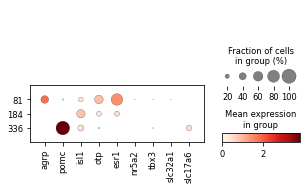

In [33]:
sc.pl.dotplot(test_adata,groupby='eq_subclass_lc',var_names = ['agrp','pomc','isl1','otp','esr1','nr5a2','tbx3','slc32a1','slc17a6'])

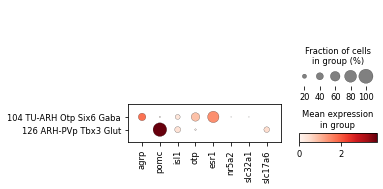

In [114]:
sc.pl.dotplot(test_adata, groupby = 'ss_subclass_v3_nounlabeled', var_names = ['agrp','pomc','isl1','otp','esr1','nr5a2','slc32a1','slc17a6'])

In [158]:
a

128

In [159]:
a 

128

In [264]:
sam.clustering(param = 30)

In [265]:
sam.adata.obs['leiden_clusters'].nunique()

357

In [266]:
a = 0
for item in sam.adata.obs_names:
    if sam.adata.obs.loc[item,'leiden_clusters'] == sam.adata.obs.loc[item,'eq_subclass_lc']:
        a += 1

In [267]:
a

42221

In [263]:
sam.adata.obs['eq_subclass_lc'].nunique()

357

In [254]:
for item in sam.adata.obs['eq_subclass_lc'].unique():
    obs_names = sam.adata.obs_names[sam.adata.obs['eq_subclass_lc'] == item]
    print(lsamap_mv.loc[obs_names,0].unique())

['Unlabeled']
['322 Tanycyte NN']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['326 OPC NN']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['056 Sst Chodl Gaba']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['327 Oligo NN']
['056 Sst Chodl Gaba']
['Unlabeled']
['101 ZI Pax6 Gaba']
['326 OPC NN']
['Unlabeled']
['107 DMH Hmx2 Gaba']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['322 Tanycyte NN']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['327 Oligo NN']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['322 Tanycyte NN']
['Unlabeled']
['Unlabeled']
['086 MPO-ADP Lhx8 Gaba']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['Unlabeled']
['107 DMH Hmx2 Gaba

In [ ]:
a = 0
ss = list(sam.adata.obs['ss_subclass'])
for i in range(len(new_mapping)):
    if new_mapping[i] != ss[i] and new_mapping[i] != 'Unlabeled':
        a += 1

In [ ]:
a

2117

In [ ]:
len([i for i in sam.adata.obs['eq_subclass'].unique() if parent_dict[parent_dict[i]] == 'hypo'])

9

In [ ]:
for item in sam.adata.obs['ss_subclass_nounlabeled'].unique():
    if item not in parent_dict:
        parent_dict[item] = 'not hypo'

In [ ]:
len([i for i in sam.adata.obs['ss_subclass_nounlabeled'].unique() if parent_dict[parent_dict[i]] == 'hypo'])

14

In [ ]:
for item in sam.adata.obs['ss_subclass_v2'].unique():
    if item not in parent_dict:
        parent_dict[item] = 'hypo'

In [ ]:
len([i for i in sam.adata.obs['ss_subclass_v2'].unique() if parent_dict[parent_dict[i]] == 'hypo'])

16

In [ ]:
 set(sam.adata.obs['ss_subclass']) - set(sam.adata.obs['ss_subclass_v2'])

set()

In [ ]:
set(sam.adata.obs['ss_subclass_v2']) - set(sam.adata.obs['ss_subclass'])

{'053 Sst Gaba', '104 TU-ARH Otp Six6 Gaba', 'dr_m041_m064'}

In [ ]:
sam.adata.obs['ss_subclass']

AAACCTGAGAGTTGGC 97                       Unlabeled
AAACCTGCAAGCGTAG 97                 322 Tanycyte NN
AAACCTGCAGTAGAGC 97                       Unlabeled
AAACCTGCATCACCCT 97                       Unlabeled
AAACCTGGTAAGAGAG 97                     333 Endo NN
                                   ...             
TTTGTCAGTTGAACTC 96                       Unlabeled
TTTGTCATCAGCTGGC 96                       Unlabeled
TTTGTCATCATCATTC 96    057 NDB-SI-MA-STRv Lhx8 Gaba
TTTGTCATCCGATATG 96                       Unlabeled
TTTGTCATCGGCCGAT 96                       Unlabeled
Name: ss_subclass, Length: 82678, dtype: category
Categories (38, object): ['010 IT AON-TT-DP Glut', '038 DG-PIR Ex IMN', '041 OB-in Frmd7 Gaba', '045 OB-STR-CTX Inh IMN', ..., '333 Endo NN', '337 DC NN', '338 Lymphoid NN', 'Unlabeled']

In [ ]:
len([i for i in sam.adata.obs['ss_subclass'] if i == 'Unlabeled'])

61616

In [365]:
len([i for i in sam.adata.obs['ss_subclass_v2'] if i == 'Unlabeled'])

59499

In [226]:
for item in sam.adata.obs_names:
    if sam.adata.obs.loc[item,'ss_subclass'] != sam.adata.obs.loc[item,'ss_subclass_v2']:
        print(sam.adata.obs.loc[item, 'eq_subclass_lc'], sam.adata.obs.loc[item,'ss_subclass_v2'])

296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba
296 100 AHN Onecut3 Gaba


In [366]:
sam.save_anndata(fn)